In [1]:
#--------------------------------------------------------------------------------------------------------------
#
#  Code: CARD03_Agentic_AI_Multiple_Month_Statement_Analysis_for_Member_Request_CLI_20260629.ipynb
#
#  Goal: To read in Jingru Chen's 3 recent own credit card statements, and study whether a member request line increase should be granted.
#
#        This Agentic AI framework leverages multi-agent orchestration. Specially, it will implement 6 different agents, including
#
#         (1) Agent 1 – Statement Parser
#             Extracts: Credit limit, Balance, Transactions, Merchant names, Payment dates, etc.
#
#         (2) Agent 2 – Spending Behavior
#             Computes: Monthly spend, Average transaction, Spend growth, Spending volatility, etc.
#
#         (3) Agent 3 – Payment Behavior
#             Calculates: Payment ratio, Full-pay frequency, Late payments, Revolving behavior, etc.
#
#         (4) Agent 4 – Utilization
#             Computes: Average utilization, Peak utilization, Available credit, Line pressure, etc.
#
#         (5) Agent 5 – Routing
#             Make Deicions of APPROVED, DECLINED, or MANUAL_REVIEW
#
#         (6) Agent 6 – Executive Summary
#             Generate:   (6-1) Decision
#                         (6-2) Decision Source
#                         (6-3) Risk Explanation
#                         (6-4) Trend Summary
#                         (6-5) Supporting Metrics
#                         (6-6) Overall Credit Assessment
#
#        Jingru Chen
#        2026-06-29
#
#---------------------------------------------------------------------------------------------------------------

In [2]:

from datetime import datetime
from zoneinfo import ZoneInfo

start = datetime.now( ZoneInfo("America/New_York"))

print( start.strftime("%Y-%m-%d %H:%M:%S %Z"))     # 2026-03-17 17:34:58 EDT
print( start.strftime("%Y-%m-%d %I:%M:%S %p %Z"))  # 2026-03-17 05:34:58 PM ED

2026-06-27 22:09:41 EDT
2026-06-27 10:09:41 PM EDT


## Step 0: Set up and install various Python packages

In [3]:
from sentence_transformers import SentenceTransformer

# Current: 384 dimensions (Fast, but lower capacity)
# embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Upgrade: 768 dimensions (Higher accuracy, captures more nuance)
embedding_model = SentenceTransformer("all-mpnet-base-v2")

# Extreme Upgrade: 1024+ dimensions (e.g., using BGE or Instructor models)
# embedding_model = SentenceTransformer("BAAI/bge-large-en-v1.5")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [4]:
# %pip install pymupdf

# PyMuPDF is a tool for working with PDF files using Python.
# PyMuPDF over others (like PyPDF2 or PDFMiner)?
# Performance: It is significantly faster than most other Python PDF libraries because the heavy lifting is done by the underlying C library.

In [5]:
# --- Dependency Installer ---

# !pip install -q langchain-openai langgraph pandas pymupdf
# --- To add -q will makes the installation "quiet," so it doesn't flood my notebook with long, messy installation logs.
# --- For testing purpose, I still print all log.

!pip install langchain-openai langgraph langsmith pandas pymupdf

In [6]:
!pip install python-dotenv

In [7]:
# !uv pip install pymupdf

# uv is a newer tool designed to be much faster than pip.

In [8]:
import os
import pandas as pd
import json
from typing import List
import fitz
import re
import numpy as np
import glob
import matplotlib.pyplot as plt

from typing import TypedDict, List, Dict, Any
from langgraph.graph import StateGraph, END

from langchain_openai import ChatOpenAI
from langsmith import Client
from langsmith.utils import LangSmithConflictError
from IPython.display import Image, display

## Step 1: Connect to my data folder in Google drive

In [9]:
pwd

'/content'

In [10]:
ls -lt

total 8
drwx------ 5 root root 4096 Jun 27 21:58 drive/
drwxr-xr-x 1 root root 4096 Jun  4 13:32 sample_data/


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# Go to the level of sample_data in my Google Drive
path = "/content/drive/MyDrive/Colab Notebooks/sample_data"

# Verify the path after the above connecting step
print(os.getcwd())

# List all files unver the sample_data folder
os.listdir(path)

/content


['chroma.sqlite3',
 '.env',
 'Jingru_WFC_Autograph_Visa_Card_statement_202606.pdf',
 'Jingru_WFC_Autograph_Visa_Card_statement_202605.pdf',
 'Jingru_WFC_Autograph_Visa_Card_statement_202604.pdf']

In [13]:
file_paths = [
        "/content/drive/MyDrive/Colab Notebooks/sample_data/stmt_202604.pdf",
        "/content/drive/MyDrive/Colab Notebooks/sample_data/stmt_202605.pdf",
        "/content/drive/MyDrive/Colab Notebooks/sample_data/stmt_202606.pdf" ]

### Step 1-B: Upload my API_KEYs for various LLM and LangSmith

In [14]:
from dotenv import load_dotenv

load_dotenv("/content/drive/MyDrive/Colab Notebooks/sample_data/.env")

# =========================
# OPENAI KEY
# =========================
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
print(f"-----------------1-B-1: Print of first 20 characters of my OPENAI_API_KEY -----: {OPENAI_API_KEY[:20]} " )  # check the first 20 charaacters of my OPENAI_API_KEY

# =========================
# LANGSMITH CONFIG
# =========================

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")

# IMPORTANT: correct project name
os.environ["LANGSMITH_PROJECT"] = "JCHEN-credit-line-risk-langgraph"

# =========================
# SAFE PRINT (correct variable)
# =========================
LANGSMITH_API_KEY = os.getenv("LANGSMITH_API_KEY")

print(f"---------------- 1-B-2: Print of first 20 characters of my LANGSMITH_API_KEY---: {LANGSMITH_API_KEY[:20]} ")

print(os.getenv("LANGSMITH_TRACING"))
print(os.getenv("LANGSMITH_PROJECT"))

# =========================
# 3. Initialize the client
# =========================
client = Client()

# =========================
# 4. Ensure the project exists
# =========================
project_name = "JCHEN-credit-line-risk-langgraph"

try:
    client.create_project(
        project_name=project_name,
        description="Credit line risk analysis pipeline"
    )
    print(f"Successfully created project: {project_name}")

except LangSmithConflictError:
    print(f"Project '{project_name}' already exists. Proceeding with existing project.")

-----------------1-B-1: Print of first 20 characters of my OPENAI_API_KEY -----: sk-proj-fezFts2agCx8 
---------------- 1-B-2: Print of first 20 characters of my LANGSMITH_API_KEY---: lsv2_pt_5f67d91ddcbc 
true
JCHEN-credit-line-risk-langgraph
Project 'JCHEN-credit-line-risk-langgraph' already exists. Proceeding with existing project.


### Step 1-C: Mini test for connecting to LangSmith

In [15]:
# # Define the State
# class AgentState(TypedDict):
#     file_path: str
#     _1_parser_summary: Dict[str, Any]
#     df_transactions: Any
#     spending_metrics: Dict[str, Any]
#     payment_metrics: Dict[str, Any]
#     utilization_metrics: Dict[str, Any]
#     final_summary: str

# workflow = StateGraph(AgentState)

# app = workflow.compile()

# llm = ChatOpenAI(model="gpt-4o")
# llm.invoke("--------------- 1-C: 2026-06-27 - test langsmith tracing")

# result = app.invoke(initial_state)

## Step 2: Upload one monthly card statement PDF file for RAG summarization

### Step 2-A: Extract major information except for my transaction history

In [16]:
# import fitz
# import re

def extract_1_statement_data(pdf_path):
    results = {
        "Account Number": None,
        "Statement Period": None,
        "Credit Limit": None,
        "Previous Balance": None,
        "Payments": [], # FIX: Initialize as an empty list, not None
        "Purchases, Balance Transfers & Other Charges": None,
        "New Balance": None,
        "Available Credit": None,
        "Rewards": None
    }

    with fitz.open(pdf_path) as doc:
        full_text = "\n".join([page.get_text() for page in doc])

    # --- 1. Extract Account Number ---
    # Looks for "Account ending in" or "Account Number"
    acc_match = re.search(r"Account (?:ending in|Number)[\s\.]*(\d+)", full_text, re.IGNORECASE)
    if acc_match: results["Account Number"] = acc_match.group(1).strip()

    # --- 2. Extract Statement Period ---
    # Looks for "Statement Period" followed by two dates
    period_match = re.search(r"Statement Period ([\d/]+ to [\d/]+)", full_text, re.IGNORECASE)
    if period_match: results["Statement Period"] = period_match.group(1).strip()

    # --- 3. Define a helper to find a number after a specific label
    def get_val(label, text):
        # This regex looks for the label, skips any characters (including newlines),
        # then finds the first dollar amount or number.
        pattern = re.escape(label) + r".*?\$?([\d,]+\.\d{2})"
        match = re.search(pattern, text, re.IGNORECASE | re.DOTALL)
        return match.group(1).replace(',', '') if match else None

    # --- 4. Extract values using the helper
    results["Previous Balance"] = get_val("Previous Balance", full_text)
    results["New Balance"] = get_val("New Balance", full_text)

    # --- 5. Note: For "Payments" and "Purchases", check the specific labels in your PDF
    # The summary table in your image uses "- Payments" and "+ Purchases..."
    results["Payments"] = get_val("- Payments", full_text)
    results["Purchases, Balance Transfers & Other Charges"] = get_val("+ Purchases", full_text)

    # --- 7. Extract Available Credit ---
    # Looks for the line starting with "Total Available Credit"
    avail_credit_match = re.search(r"Total Available Credit.*?([\d,]+)", full_text, re.IGNORECASE | re.DOTALL)
    if avail_credit_match: results["Available Credit"] = avail_credit_match.group(1).strip()

    # --- 8. Extract Rewards Balance ---
    # Look for the line containing "Rewards balance as of"
    # and specifically find a number that contains a comma
    rew_match = re.search(r"Rewards balance as of:.*?\s(\d{1,3},\d{3})", full_text, re.IGNORECASE | re.DOTALL)
    if rew_match:
        results["Rewards"] = rew_match.group(1).strip()

    # --- 5. Existing logic for Credit Limit and Balance
    limit_match = re.search(r"Credit Limit.*?([\d,]{2,})", full_text, re.IGNORECASE | re.DOTALL)
    if limit_match: results["Credit Limit"] = limit_match.group(1).strip()

    bal_match = re.search(r"New Balance.*?([\d,]+\.\d{2})", full_text, re.IGNORECASE | re.DOTALL)
    if bal_match: results["Balance"] = bal_match.group(1).strip()

    return results

# --- Execution ---
file_path = "/content/drive/MyDrive/Colab Notebooks/sample_data/Jingru_WFC_Autograph_Visa_Card_statement_202605.pdf"
data_1_parsed_info = extract_1_statement_data(file_path)

print(f"\n---------------- Print Entire output----------------------:\n {data_1_parsed_info}")
print("\n---------------- Print Entire output in Jason format ----------------------")
print(json.dumps(data_1_parsed_info, indent=4))


---------------- Print Entire output----------------------:
 {'Account Number': '3150', 'Statement Period': '04/10/2026 to 05/10/2026', 'Credit Limit': '30,000', 'Previous Balance': '3684.76', 'Payments': '4425.13', 'Purchases, Balance Transfers & Other Charges': '2426.02', 'New Balance': '1685.65', 'Available Credit': '28,314', 'Rewards': '7,066', 'Balance': '1,685.65'}

---------------- Print Entire output in Jason format ----------------------
{
    "Account Number": "3150",
    "Statement Period": "04/10/2026 to 05/10/2026",
    "Credit Limit": "30,000",
    "Previous Balance": "3684.76",
    "Payments": "4425.13",
    "Purchases, Balance Transfers & Other Charges": "2426.02",
    "New Balance": "1685.65",
    "Available Credit": "28,314",
    "Rewards": "7,066",
    "Balance": "1,685.65"
}


### Step 2-B: Extract my transaction history ONLY

In [17]:
def extract_2_transaction_data(pdf_path):
    results = {
        "Account Number": None,
        "Statement Period": None,
        "Transactions": []
    }

    with fitz.open(pdf_path) as doc:
        full_text = "\n".join([page.get_text() for page in doc])

    # --- 1. NEW: Extract Account Number ---
    # Looks for "Account ending in" or "Account Number"
    acc_match = re.search(r"Account (?:ending in|Number)[\s\.]*(\d+)", full_text, re.IGNORECASE)
    if acc_match: results["Account Number"] = acc_match.group(1).strip()

    # --- 2. NEW: Extract Statement Period ---
    # Looks for "Statement Period" followed by two dates
    period_match = re.search(r"Statement Period ([\d/]+ to [\d/]+)", full_text, re.IGNORECASE)
    if period_match: results["Statement Period"] = period_match.group(1).strip()

    # --- 7. NEW: Extract Statement Period ---
    transaction_match = re.search(
    r"Purchases, Balance Transfers & Other Charges(.*?)(?=Interest Charged|Fees Charged|TOTAL PURCHASES)",
    full_text,
    re.I | re.S
)
    transaction_text = transaction_match.group(1)

    lines = [x.strip() for x in transaction_text.splitlines() if x.strip()]

    transactions = []

    i = 0

    while i < len(lines):

        # Transaction Date
        if re.fullmatch(r"\d{2}/\d{2}", lines[i]):

            trans_date = lines[i]

            # Skip Post Date
            if i + 1 < len(lines) and re.fullmatch(r"\d{2}/\d{2}", lines[i+1]):
                i += 1

            reference = None
            description = None
            amount = None

            # Reference Number
            if i + 1 < len(lines):
                reference = lines[i+1]

            # Description
            if i + 2 < len(lines):
                description = lines[i+2]

            # Amount
            for j in range(i+3, min(i+8, len(lines))):

                if re.fullmatch(r"[\d,]+\.\d{2}", lines[j]):

                    amount = lines[j]
                    break

            if amount:

                transactions.append({
                    "date": trans_date,
                    "reference": reference,
                    "description": description,
                    "amount": amount
                })

        i += 1

    results["Transactions"] = transactions

    return results

# --- Execution ---
file_path = "/content/drive/MyDrive/Colab Notebooks/sample_data/Jingru_WFC_Autograph_Visa_Card_statement_202605.pdf"
data_2_parsed_info = extract_2_transaction_data(file_path)

# Print specific fields
print(f"Account Number: {data_2_parsed_info['Account Number']}")
print(f"Statement Period: {data_2_parsed_info['Statement Period']}")
print(f"Transacton History: {data_2_parsed_info['Transactions']}")

print(f"\n---------------- Print Entire output----------------------:\n {data_2_parsed_info}")

print("\n---------------- Print Entire output in Jason format ----------------------")
# Create a copy so we don't modify the original
preview_data = data_2_parsed_info.copy()
# Show only the first 2 payments
preview_data["Transactions"] = preview_data["Transactions"][:2]

print("\n---------------- Partial JSON (First 2 Transactons) ----------------------")
print(json.dumps(preview_data, indent=4))

Account Number: 3150
Statement Period: 04/10/2026 to 05/10/2026
Transacton History: [{'date': '04/08', 'reference': '2426979FKEJAQSMHL', 'description': 'TAKUMI - WILMINGTON WILMINGTON  DE', 'amount': '227.64'}, {'date': '04/09', 'reference': '2494300FKBXTSKGLG', 'description': 'STATE FARM  INSURANCE    800-956-6310 IL', 'amount': '49.33'}, {'date': '04/12', 'reference': '2445501FN43ADTWW4', 'description': 'SAMSCLUB #6343 RICHMOND  VA', 'amount': '133.00'}, {'date': '04/12', 'reference': '2469216FNBVSV65HP', 'description': 'INTUIT *TURBOTAX CL.INTUIT.COM CA', 'amount': '45.00'}, {'date': '04/12', 'reference': '2469216FNBVTD8GK2', 'description': 'INTUIT *TURBOTAX CL.INTUIT.COM CA', 'amount': '45.00'}, {'date': '04/12', 'reference': '2469216FNBVTYR351', 'description': 'INTUIT *TURBOTAX CL.INTUIT.COM CA', 'amount': '35.00'}, {'date': '04/13', 'reference': '2413746FR016BQE8Z', 'description': 'USPS PO 5135820260 GLEN ALLEN  VA', 'amount': '43.60'}, {'date': '04/13', 'reference': '2469216FPBW

In [18]:
# 1. Convert the list of dictionaries directly into a DataFrame
df_2_trans = pd.DataFrame(data_2_parsed_info["Transactions"])

df_2_trans = df_2_trans.drop( columns= [ "reference" ])   # drop the reference column which may not be useful

df_2_trans["Account Number"] = data_2_parsed_info["Account Number"]
df_2_trans["Statement Period"] = data_2_parsed_info["Statement Period"]

# 2. Clean the 'amount' column
# We replace the comma and convert to float so we can perform math on it
df_2_trans['amount'] = df_2_trans['amount'].str.replace(',', '', regex=False).astype(float)

df_2_trans= df_2_trans[['Account Number',	'Statement Period', 'date',	'description',	'amount' ]]

# 3. View the first 5 transaction history of my credit card statement
df_2_trans.head()

,Account Number,Statement Period,date,description,amount
0,3150,04/10/2026 to 05/10/2026,04/08,TAKUMI - WILMINGTON WILMINGTON DE,227.64
1,3150,04/10/2026 to 05/10/2026,04/09,STATE FARM INSURANCE 800-956-6310 IL,49.33
2,3150,04/10/2026 to 05/10/2026,04/12,SAMSCLUB #6343 RICHMOND VA,133.00
3,3150,04/10/2026 to 05/10/2026,04/12,INTUIT *TURBOTAX CL.INTUIT.COM CA,45.00
4,3150,04/10/2026 to 05/10/2026,04/12,INTUIT *TURBOTAX CL.INTUIT.COM CA,45.00


In [19]:
monthly_spend = df_2_trans.amount.sum()

average_transaction = df_2_trans.amount.mean()

transaction_count = len(df_2_trans)

top3 = df_2_trans.nlargest(3, "amount")

print(monthly_spend)
print(average_transaction)
print(transaction_count)
top3

2426.02
101.08416666666666
24


,Account Number,Statement Period,date,description,amount
19,3150,04/10/2026 to 05/10/2026,05/03,GEORGE MASON UNIV MKTP 703-9936622 VA,425.00
16,3150,04/10/2026 to 05/10/2026,05/02,STATE FARM INSURANCE 800-956-6310 IL,274.98
17,3150,04/10/2026 to 05/10/2026,05/02,COSTCO WHSE #0205 GLEN ALLEN VA,251.05


### Step 2-C: Calculate payment statistics

### Payment ratio, Full-pay frequency, Late payments, Revolving behavior, etc.


In [20]:
data_1_parsed_info

{'Account Number': '3150',
 'Statement Period': '04/10/2026 to 05/10/2026',
 'Credit Limit': '30,000',
 'Previous Balance': '3684.76',
 'Payments': '4425.13',
 'Purchases, Balance Transfers & Other Charges': '2426.02',
 'New Balance': '1685.65',
 'Available Credit': '28,314',
 'Rewards': '7,066',
 'Balance': '1,685.65'}

In [21]:
def extract_3_payment_data(summary: dict,
                           df_transactions: pd.DataFrame):
    """
    Calculate payment behavior metrics.
    Inputs:
      --- summary: output from extract_1_statement_data()
      --- df_transactions:  DataFrame created by Agent 2

    Returns:   payment_metrics (dict)
    """

    ##################################################
    # Total Payments
    ##################################################

    payments = summary.get("Payments", [])

    total_payments = 0.0

    if isinstance(payments, list):

        for p in payments:
            if isinstance(p, dict):
                total_payments += float(
                    p["amount"].replace(",", "")
                )

            elif isinstance(p, str):
                total_payments += float(
                    p.replace(",", "")
                )

    elif isinstance(payments, str):
        total_payments = float(
            payments.replace(",", "")  )

    ##################################################
    # Previous Balance
    ##################################################

    previous_balance = float( summary.get("Previous Balance", "0").replace(",", "") )

    ##################################################
    # New Balance
    ##################################################

    new_balance = float(
        summary.get("Balance", "0").replace(",", "") )

    ##################################################
    # Payment Ratio
    ##################################################

    if previous_balance > 0:
        payment_ratio = total_payments / previous_balance

    else:
        payment_ratio = 0

    ##################################################
    # Full Pay?
    ##################################################

    full_pay = total_payments >= previous_balance

    ##################################################
    # Late Fee Count
    ##################################################

    if (
        not df_transactions.empty
        and "description" in df_transactions.columns
    ):

        late_count = len(
            df_transactions[
                df_transactions["description"]
                .str.contains(
                    "LATE|FEE",
                    case=False,
                    na=False
                )
            ]

        )

    else:

        late_count = 0

    ##################################################
    # Revolving?
    ##################################################

    revolving = (new_balance > 0) and (not full_pay)

    ##################################################
    # Output
    ##################################################

    payment_metrics = {

        "total_payments": round(total_payments,2),
        "Payment Ratio (%)": f"{round(payment_ratio * 100, 2)}%",
        "full_pay": full_pay,
        "late_payment_count": late_count,
        "revolving": revolving
    }

    return payment_metrics

### Step 2-D: Calculate Line Utilization statistics

In [22]:
def extract_4_line_utilization(summary,
                               df_transactions):

    def to_float(x):

        if x is None:
            return 0.0

        if isinstance(x, str):
            return float(x.replace(",", ""))

        return float(x)

    ##################################################
    # Values from summary
    ##################################################

    credit_limit = to_float(summary.get("Credit Limit",0))
    current_balance = to_float(summary.get("Balance",0))
    previous_balance = to_float(summary.get("Previous Balance",0))
    available_credit = to_float(summary.get("Available Credit",0))

    ##################################################
    # Spending
    ##################################################

    total_spend = df_transactions["amount"].sum()

    ##################################################
    # Metrics
    ##################################################

    avg_utilization = (
        current_balance / credit_limit * 100
        if credit_limit > 0 else 0   )

    peak_balance = previous_balance + total_spend

    peak_utilization = (
        peak_balance / credit_limit * 100
        if credit_limit > 0 else 0    )

    line_pressure = (
        current_balance / credit_limit
        if credit_limit > 0 else 0   )

    metrics = {

        "Average Utilization (%)": f"{round(avg_utilization , 2)}%",
        "Peak Utilization (%)":    f"{round(peak_utilization,2)}%",
        "Available Credit ($)":    round(available_credit,2)
         }

    return metrics

# print(pd.Series(metrics))

# Average Utilization (%)        5.620
# Peak Utilization (%)          20.370
# Available Credit ($)       28314.000
# Line Pressure (Ratio)          0.056
# dtype: float64

## Step 3: LangGraph

### Step 3-A: Define the Shared State
#### Goal: Create a common "State" that all agents will read from and update.

### Step 3-B: Implement the Agent Functions
#### Gaol: Each function below represents one of your agents.

In [23]:
class AgentState(TypedDict):
    file_paths: List[str]
    _1_parser_summary: Dict[str, Any]     # from extract_1_statement_data()
    _df_transaction  : Any                  # pandas DataFrame
    _2_spending_metrics: Dict[str, Any]
    _3_payment_metrics: Dict[str, Any]
    _4_utilization_metrics: Dict[str, Any]
    _5_MRLI_review_summary: str
    decision: str          # NEW
    reason: str            # NEW

In [24]:
# Add a function to pull a monthly statement PDF file
def get_month_label(file_path: str):
    """
    Extracts a month label from filename.
    Example: ...202604.pdf → 202604
    """

    import re

    match = re.search(r"20\d{4}", file_path)
    if match:
        return match.group(0)

    # fallback if pattern not found
    return file_path.split("/")[-1]

# Agent 1 only parses the statement summary.
def agent_1_parser(state: AgentState):

    monthly_summaries = {}

    for file_path in state["file_paths"]:
        month = get_month_label(file_path)
        monthly_summaries[month] = extract_1_statement_data(file_path)

    return {"_1_parser_summary": monthly_summaries}

# Agent 2 creates the DataFrame once, stores it in the state, and computes metrics from it.
# For LangGraph, don't store a pandas DataFrame in the graph state. store it outside the state.
transaction_cache = {}

def agent_2_spending(state: AgentState):

    monthly_metrics = {}
    dfs = []

    for file_path in state["file_paths"]:

        month = get_month_label(file_path)

        raw_data = extract_2_transaction_data(file_path)
        df = pd.DataFrame(raw_data["Transactions"])

        if not df.empty:
            df["amount"] = df["amount"].str.replace(",", "").astype(float)

        df["month"] = month
        dfs.append(df)

        monthly_metrics[month] = {
            "spend": df["amount"].sum(),
            "avg_txn": df["amount"].mean(),
            "txn_count": len(df),
            "max_txn": df["amount"].max()
        }

    full_df = pd.concat(dfs, ignore_index=True)
    transaction_cache["ALL"] = full_df

    # 🔥 Trend analysis
    months_sorted = sorted(monthly_metrics.keys())

    trend = {
        "spend_trend": [monthly_metrics[m]["spend"] for m in months_sorted],
        "spend_growth": (
            monthly_metrics[months_sorted[-1]]["spend"]
            - monthly_metrics[months_sorted[0]]["spend"]
        )
    }

    return {
        "_2_spending_metrics": {
            "monthly": monthly_metrics,
            "trend": trend
        }
    }

# Agent 3 use the derived DataFrame from Agent 2 to calculate payment statistics
def agent_3_payment(state: AgentState):

    df = transaction_cache["ALL"]

    monthly = {}
    full_summary = state["_1_parser_summary"]

    for month in full_summary.keys():

        df_m = df[df["month"] == month]

        monthly[month] = extract_3_payment_data(
            summary=full_summary[month],
            df_transactions=df_m
        )

    # 🔥 trend logic
    full_pay_months = sum(1 for m in monthly if monthly[m].get("full_pay"))

    return {
        "_3_payment_metrics": {
            "monthly": monthly,
            "full_pay_consistency": full_pay_months / len(monthly)
        }
    }

# Agent 4 use the derived DataFrame from Agent 2 to calculate credit line utilization statistics
def agent_4_utilization(state):

    df = transaction_cache["ALL"]
    full_summary = state["_1_parser_summary"]

    monthly = {}

    for month in full_summary.keys():

        df_m = df[df["month"] == month]

        monthly[month] = extract_4_line_utilization(
            summary=full_summary[month],
            df_transactions=df_m
        )

    # 🔥 detect risk spike
    peak_util = max(
        float(monthly[m]["Peak Utilization (%)"].replace("%", ""))
        for m in monthly
    )

    # For creating a chart: build chart-ready utilization trend data
    util_data = []
    for m, v in monthly.items():
        util_data.append({
            "month": m,
            "utilization": float(v["Average Utilization (%)"].replace("%", ""))
        })

    return {
        "_4_utilization_metrics": {
            "monthly": monthly,
            "peak_across_3m": peak_util,
            "risk_flag": peak_util > 90
        }
    }

# Agent 5 use LLM (i.e. gpt-4o) to analyze the first 4 agent's findings, and make final recommendation on whether a member requested line increase is warranted.
def agent_5_executive_summary(state: AgentState):

    llm = ChatOpenAI(model="gpt-4o", temperature=0)

    prompt = f"""
    You are a Senior Credit Risk Underwriter preparing
    an internal underwriting memorandum.

    ==================================================
    FINAL DECISION
    ==================================================

    Decision:
    {state["decision"]}

    Decision Source:
    {state.get("review_type", state.get("decision", "UNKNOWN"))}

    Reason:
    {state["reason"]}

    ==================================================
    SPENDING METRICS
    ==================================================

    {state["_2_spending_metrics"]}

    ==================================================
    PAYMENT METRICS
    ==================================================

    {state["_3_payment_metrics"]}

    ==================================================
    UTILIZATION METRICS
    ==================================================

    {state["_4_utilization_metrics"]}

    --------------------------------------------------

    The decision has ALREADY been made.

    Do NOT change it.

    Instead, explain WHY the policy engine reached this decision.

    Return:

    1. Decision
    2. Decision Source
    3. Risk Explanation
    4. Trend Summary
    5. Supporting Metrics
    6. Overall Credit Assessment

    Write in professional banking language.

    Reference actual numerical values whenever possible.

    Do not invent facts.
    """

    response = llm.invoke(prompt)

    return {"_5_MRLI_review_summary": response.content}


# Agent 6 Use a Router agent to make decision based on various conditions
def agent_6_router(state: AgentState):

    util = state["_4_utilization_metrics"]["peak_across_3m"]
    payment = state["_3_payment_metrics"]

    full_pay_consistency = payment["full_pay_consistency"]

    late_payments = sum(
        month.get("late_payment_count", 0)
        for month in payment["monthly"].values()
    )

    if util < 50 and late_payments == 0 and full_pay_consistency == 1.0:
        return {
            "decision": "APPROVED",
            "reason": "...",
            "review_type": "AUTO_APPROVAL"
        }

    if util > 90 and late_payments >= 3:
        return {
            "decision": "DECLINED",
            "reason": "...",
            "review_type": "AUTO_DECLINE"
        }

    return {
        "decision": "MANUAL_REVIEW",
        "reason": "...",
        "review_type": "MANUAL_REVIEW"
    }

# Step 07 - route decision
def route_decision(state: AgentState):

    if state["decision"] == "APPROVED":
        return "approve"

    elif state["decision"] == "DECLINED":
        return "decline"

    else:
        return "manual_review"

# Step 08: auto approval
def auto_approve(state):

    return {
        "decision": "APPROVED",
        "reason": state["reason"],
        "review_type": "AUTO_APPROVAL"
    }

# Step 09: auto decline
# def auto_decline(state: AgentState):

#     return {
#         "_5_MRLI_review_summary":
#         f"""
#         Decision: {state['decision']}

#         Reason:
#         {state['reason']}
#         """
#     }

def auto_decline(state):

    return {
        "decision": "DECLINED",
        "reason": state["reason"],
        "review_type": "AUTO_DECLINE"
    }

def manual_review(state):
    return {
        **state,
        "review_type": "MANUAL_REVIEW",
        "decision": state["decision"],
        "reason": state["reason"]
    }

# Store the DataFrame internally, don't return it in the final output
def agent_cleanup(state: AgentState):
    state.pop("_df_transaction", None)
    return state

# 1. Ensure my lang-graph is built first
workflow = StateGraph(AgentState)

# 2. Add 5 nodes (Agent 1 through 5)

workflow.add_node("parser", agent_1_parser)
workflow.add_node("spending", agent_2_spending)
workflow.add_node("payment", agent_3_payment)
workflow.add_node("utilization", agent_4_utilization)

# workflow.add_node("router", agent_6_router)
# workflow.add_node("approve", auto_approve)
# workflow.add_node("decline", auto_decline)
# workflow.add_node("manual_review", manual_review)
# workflow.add_node("summary", agent_5_executive_summary)

workflow.add_node("router", agent_6_router)
workflow.add_node("approve", auto_approve)
workflow.add_node("decline", auto_decline)
workflow.add_node("summary", agent_5_executive_summary)

workflow.add_node("manual_review", manual_review)
workflow.set_entry_point("parser")

workflow.add_edge("parser", "spending")
workflow.add_edge("spending", "payment")
workflow.add_edge("payment", "utilization")
workflow.add_edge("utilization", "router")

workflow.add_conditional_edges(
    "router",
    route_decision,
    {
        "approve": "approve",
        "decline": "decline",
        "manual_review": "manual_review",
    },
)

workflow.add_edge("approve", "summary")
workflow.add_edge("decline", "summary")
workflow.add_edge("manual_review", "summary")
workflow.add_edge("summary", END)

# 4. CRITICAL: Compile the graph to create the 'app' variable
app = workflow.compile()

# 5. Here I can invoke the app
initial_state = {
    "file_paths": [
        "/content/drive/MyDrive/Colab Notebooks/sample_data/Jingru_WFC_Autograph_Visa_Card_statement_202604.pdf",
        "/content/drive/MyDrive/Colab Notebooks/sample_data/Jingru_WFC_Autograph_Visa_Card_statement_202605.pdf",
        "/content/drive/MyDrive/Colab Notebooks/sample_data/Jingru_WFC_Autograph_Visa_Card_statement_202606.pdf"
    ]
}

result = app.invoke(initial_state)

# Ensure you are using the latest version of langgraph
# The visualizer in LangSmith Studio works best when it can 'read' the graph definition
# from your remote execution.

# To see the path taken in LangSmith:
# Go to the 'Tracing' tab in the LangSmith UI (not the Studio tab)
# Click on the specific trace run.
# You will see the 'Graph' view inside the Trace window which shows
# exactly which nodes were activated in your specific execution.

result

{'file_paths': ['/content/drive/MyDrive/Colab Notebooks/sample_data/Jingru_WFC_Autograph_Visa_Card_statement_202604.pdf',
  '/content/drive/MyDrive/Colab Notebooks/sample_data/Jingru_WFC_Autograph_Visa_Card_statement_202605.pdf',
  '/content/drive/MyDrive/Colab Notebooks/sample_data/Jingru_WFC_Autograph_Visa_Card_statement_202606.pdf'],
 '_1_parser_summary': {'202604': {'Account Number': '3150',
   'Statement Period': '03/11/2026 to 04/09/2026',
   'Credit Limit': '30,000',
   'Previous Balance': '1092.46',
   'Payments': '2092.46',
   'Purchases, Balance Transfers & Other Charges': '6207.18',
   'New Balance': '3684.76',
   'Available Credit': '26,076',
   'Rewards': '27,356',
   'Balance': '3,684.76'},
  '202605': {'Account Number': '3150',
   'Statement Period': '04/10/2026 to 05/10/2026',
   'Credit Limit': '30,000',
   'Previous Balance': '3684.76',
   'Payments': '4425.13',
   'Purchases, Balance Transfers & Other Charges': '2426.02',
   'New Balance': '1685.65',
   'Available Cr

In [25]:

# 1. Get the summary
summary = result['_5_MRLI_review_summary']

# 1. Clean the string first:
# Fix common LLM formatting issues where headers get split by newlines
summary = re.sub(r'\*\*\n+', '**\n', summary)

# 2. Add a blank line ONLY before these specific headers:
# Spending Analysis, Payment Behavior, Utilization Metrics, Conclusion
# We use a non-capturing group to target these specific titles
headers_to_space = r'(?=\*\*(Spending Analysis|Payment Behavior|Utilization Metrics|Conclusion):)'
pretty = re.sub(headers_to_space, '\n', summary)

# 3. Apply bullet-point logic to split sentences
# We look for a period followed by a space, but ensure we don't break existing lists
pretty = re.sub(r'\.\s+(?=[A-Z])', '.\n- ', pretty)

# 4. Print
print(pretty)

1. **Decision**  
   APPROVED

2. **Decision Source**  
   APPROVED

3. **Risk Explanation**  
   The decision to approve the credit application is supported by a comprehensive analysis of the applicant's spending, payment, and utilization metrics.
- The applicant demonstrates a strong payment history with consistent full payments over the past three months, as evidenced by a full pay consistency ratio of 1.0.
- There are no late payments recorded, and the applicant does not revolve their credit, indicating responsible credit management.
- Additionally, the utilization metrics show low average and peak utilization rates, with a peak utilization of only 24.33% across the three-month period, suggesting prudent use of available credit.

4. **Trend Summary**  
   The spending trend over the past three months shows a decrease in total spend from $6,207.18 in April 2026 to $2,388.53 in June 2026, resulting in a negative spend growth of $3,818.65.
- This decline in spending could indicate a c

[{'month': '202604', 'utilization': 12.28}, {'month': '202605', 'utilization': 5.62}, {'month': '202606', 'utilization': 7.15}]


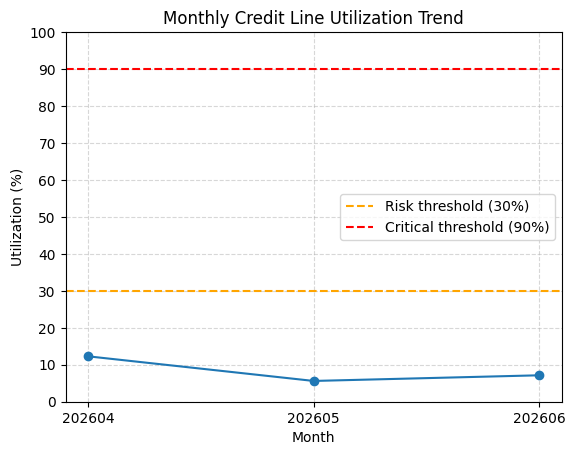

In [26]:
def build_utilization_chart(util_data):

    return {
        "chartType": "line",
        "meta": {
            "title": "Monthly Credit Utilization Trend",
            "description": "Tracks how utilization changes over time."
        },
        "xKey": "month",
        "xAxisLabel": "Month",
        "series": [
            {
                "dataKey": "utilization",
                "label": "Utilization (%)",
                "valueSuffix": "%",
                "valueFormat": "raw"
            }
        ],
        "data": util_data
    }

util_data = []

for m, v in result["_4_utilization_metrics"]["monthly"].items():
    util_data.append({
        "month": m,
        "utilization": float(v["Average Utilization (%)"].replace("%", ""))
    })

print(util_data)

build_utilization_chart(util_data)

months = [x["month"] for x in util_data]
values = [x["utilization"] for x in util_data]

plt.plot(months, values, marker='o')

plt.title("Monthly Credit Line Utilization Trend")
plt.xlabel("Month")
plt.ylabel("Utilization (%)")

# ✅ Force y-axis from 0% to 100%
plt.ylim(0, 100)

# ✅ Set 10% increments
plt.yticks(range(0, 101, 10))

plt.grid(True, linestyle='--', alpha=0.5)

plt.axhline(30, color='orange', linestyle='--', label='Risk threshold (30%)')
plt.axhline(90, color='red', linestyle='--', label='Critical threshold (90%)')
plt.legend()

plt.show()


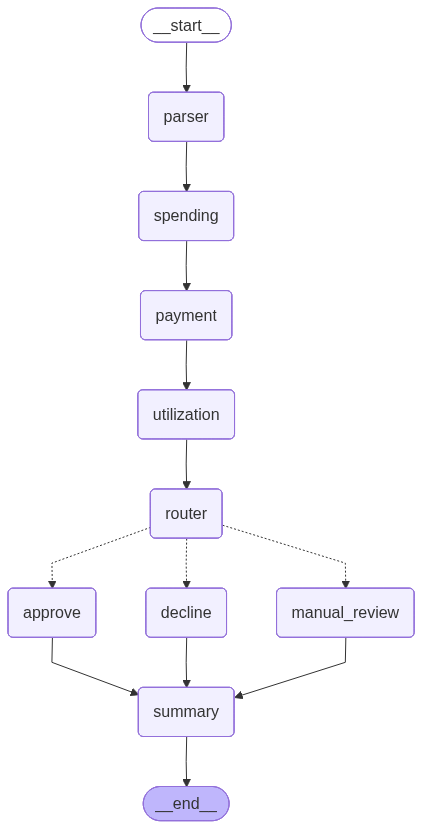

In [27]:
# This generates a PNG of your specific workflow structure
display(Image(app.get_graph().draw_mermaid_png()))

In [28]:
from datetime import datetime
end = datetime.now(ZoneInfo("America/New_York"))
duration = end - start

print(f"Started:  {start}")
print(f"Finished: {end}")
print(f"\nDuration: {duration}")                    # 0:00:02.351234
print(f"Duration: {duration.total_seconds():.3f} seconds")

Started:  2026-06-27 22:09:41.370968-04:00
Finished: 2026-06-27 22:10:47.609853-04:00

Duration: 0:01:06.238885
Duration: 66.239 seconds
